<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Nina van Iperen\AppData\Local\Temp\ipykernel_37428\3165541176.py:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('Particle size $\mu m$')
C:\Users\Nina van Iperen\AppData\Local\Temp\ipykernel_37428\3165541176.py:32: SyntaxWarning: "\m" is an invalid escape

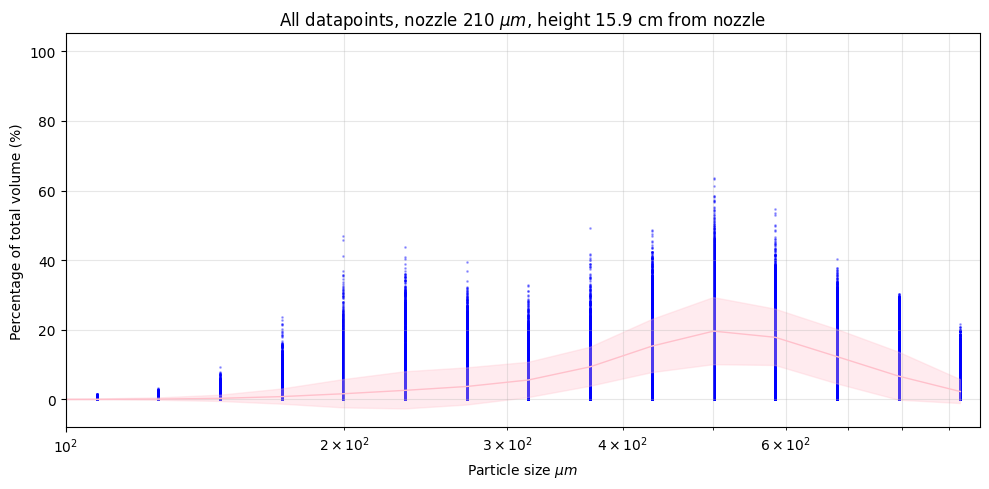

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

map_pad = r'C:\manimations\metingenh3' #hier komen bestanden vandaan deze staan in metingenh1
bestanden = list(Path(map_pad).glob('*.txt')) 

alle_dfs = [] #er wordt een lijst van bestanden gemaakt waarin alle datapunten verzameld worden 
for bestand in bestanden:
    df = pd.read_csv(bestand, sep=',', encoding='latin-1')
    df['bestand'] = bestand.stem
    alle_dfs.append(df)

data = pd.concat(alle_dfs, ignore_index=True) 

dist_cols = [col for col in data.columns if col.startswith('% V (') and 'µm)' in col] #zoekt de juiste kolom en zet de floats in de array
sizes = []
for col in dist_cols:
    low, high = col.replace('% V (', '').replace('µm)', '').split('-')
    sizes.append(np.sqrt(float(low) * float(high)))
sizes = np.array(sizes)
alle_x = np.tile(sizes, len(data))
alle_y = data[dist_cols].values.flatten()

fig, ax = plt.subplots(figsize=(10, 5)) #plotje maken op logaritmische schaal voor de mooi
ax.scatter(alle_x, alle_y, s=1, alpha=0.3, color='blue')
ax.set_xscale('log')
ax.set_xlim(100, sizes[-1] * 1.05)
ax.set_xlabel('Particle size $\mu m$')
ax.set_ylabel('Percentage of total volume (%)')
ax.set_title(f'All datapoints, nozzle 210 $\mu m $, height 15.9 cm from nozzle'  )
mean = data[dist_cols].mean().values
std_dev = data[dist_cols].std().values
ax.plot(sizes, mean,color='pink', linewidth=1, label='Gemiddelde')
ax.fill_between(sizes, mean - std_dev, mean + std_dev, alpha=0.3, color='pink', label='± std')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Aantal bins: 60
Groottebereik: 0.10816653826391968 tot 1389.1811831582659 µm
Totaal metingen: 12000


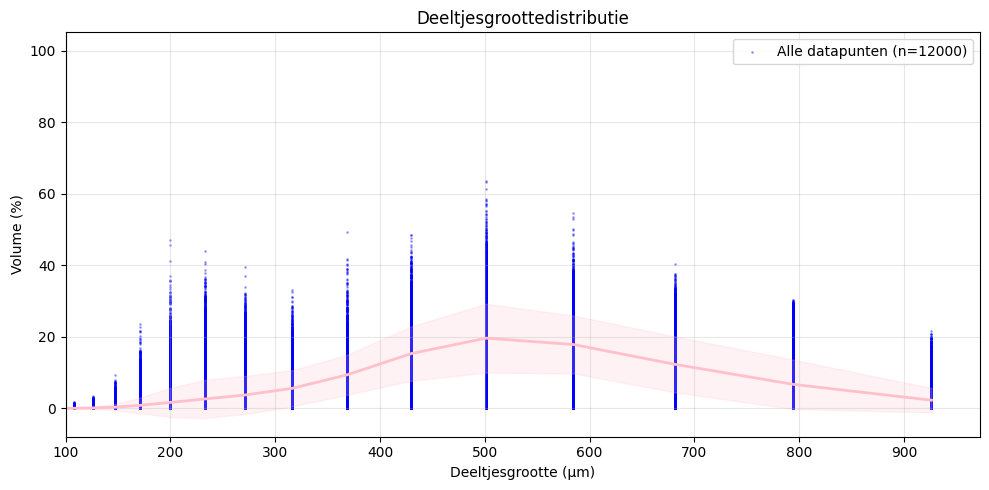

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.integrate import trapezoid

# deze is precies hetzelfde als hierboven maar dan linear met een mean
map_pad = r'C:\manimations\metingenh3'
bestanden = list(Path(map_pad).glob('*.txt'))

alle_dfs = []
for bestand in bestanden:
    df = pd.read_csv(bestand, sep=',', encoding='latin-1')
    alle_dfs.append(df)

data = pd.concat(alle_dfs, ignore_index=True)
dist_cols = [col for col in data.columns if col.startswith('% V (')]
sizes = []
for col in dist_cols:
    parts = col.replace('% V (', '').replace('µm)', '').split('-')
    low, high = float(parts[0]), float(parts[1])
    sizes.append(np.sqrt(low * high))
sizes = np.array(sizes)

print("Aantal bins:", len(sizes))
print("Groottebereik:", sizes[0], "tot", sizes[-1]*1.5, "µm")
print("Totaal metingen:", len(data))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(alle_x, alle_y, s=1, alpha=0.3, color='blue', label=f'Alle datapunten (n={len(data)})')
ax.set_xscale('linear')
ax.set_xlim(100, sizes[-1] * 1.05)
ax.set_xlabel('Deeltjesgrootte (µm)')
ax.set_ylabel('Volume (%)')
ax.set_title('Deeltjesgroottedistributie')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
mean = data[dist_cols].mean().values
std_dev = data[dist_cols].std().values
ax.plot(sizes, mean,color='pink', linewidth=2, label='Gemiddelde')
ax.fill_between(sizes, mean - std_dev, mean + std_dev, alpha=0.2, color='pink', label='± std')
plt.tight_layout()
plt.show()

[[Model]]
    Model(gaussian)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 15
    # variables        = 3
    chi-square         = 8.50442122
    reduced chi-square = 0.70870177
    Akaike info crit   = -2.51196045
    Bayesian info crit = -0.38780984
    R-squared          = 0.98668893
[[Variables]]
    amplitude:  7498.32311 +/- 216.256113 (2.88%) (init = 7390.827)
    center:     547.104466 +/- 5.28207175 (0.97%) (init = 549.1731)
    sigma:      154.897909 +/- 4.90097605 (3.16%) (init = 125.7133)
    fwhm:       364.756695 +/- 11.5409164 (3.16%) == '2.3548200*sigma'
    height:     19.3120635 +/- 0.55682015 (2.88%) == '0.3989423*amplitude/max(1e-15, sigma)'
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, sigma)  = +0.5488
    C(amplitude, center) = +0.3343
    C(center, sigma)     = +0.3044


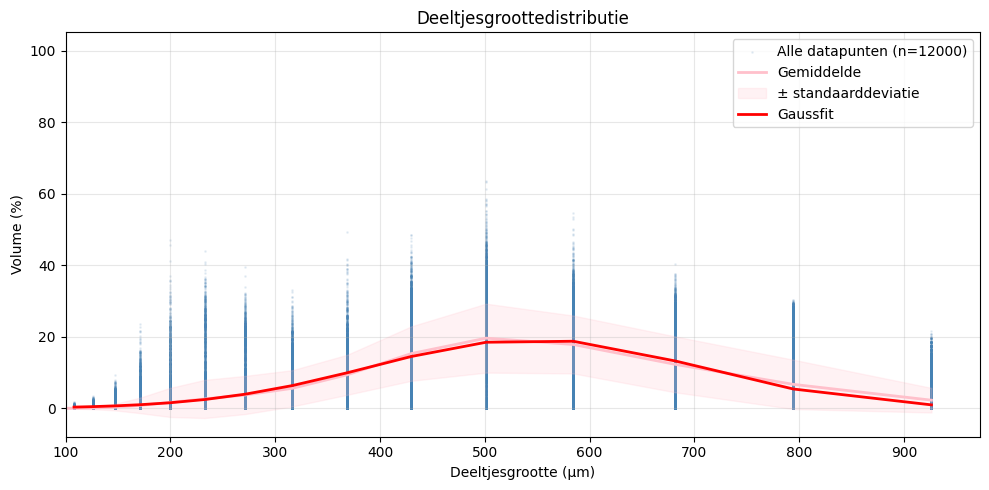

In [8]:
from lmfit.models import GaussianModel

mask = sizes > 100
model = GaussianModel()
params = model.guess(mean[mask], x=sizes[mask])
result = model.fit(mean[mask], params, x=sizes[mask])

print(result.fit_report())

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(alle_x, alle_y, s=1, alpha=0.1, color='steelblue', label=f'Alle datapunten (n={len(data)})')
ax.plot(sizes, mean, color='pink', linewidth=2, label='Gemiddelde')
ax.fill_between(sizes, mean - std_dev, mean + std_dev, alpha=0.2, color='pink', label='± standaarddeviatie')
ax.plot(sizes[mask], result.best_fit, color='red', linewidth=2, label='Gaussfit')

ax.set_xlabel(r'Deeltjesgrootte (µm)')
ax.set_ylabel(r'Volume (%)')
ax.set_title(r'Deeltjesgroottedistributie')
ax.set_xlim(100, sizes[-1] * 1.05)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import norm

mu        = result.params['center'].value
sigma     = result.params['sigma'].value
mu_err    = result.params['center'].stderr
sigma_err = result.params['sigma'].stderr

grens = 2 * 210

kans = 1 - norm.cdf(grens, loc=mu, scale=sigma)

dkans_dmu    = norm.pdf(grens, loc=mu, scale=sigma)
dkans_dsigma = norm.pdf(grens, loc=mu, scale=sigma) * (grens - mu) / sigma**2 * sigma

kans_err = np.sqrt((dkans_dmu * mu_err)**2 + (dkans_dsigma * sigma_err)**2)

print(f"Grens:  {grens} µm (2 × 210µm)")
print(f"Kans:   {kans*100:.2f} ± {kans_err*100:.2f} %")

Grens:  420 µm (2 × 210µm)
Kans:   79.41 ± 1.22 %
